# machine learning

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('experience_vs_salary.csv')
data.head()

,Experience (Years),Salary ($)
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000


In [3]:
data.rename(columns={'Experience (Years)':'Experience','Salary ($)':'Salary'},inplace=True)

In [4]:
data

,Experience,Salary
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000
5,6,60000
6,7,65000
7,8,75000
8,9,85000
9,10,95000


In [5]:
X= data[['Experience']]
y=data['Salary']

### check the relationship between exp and sal

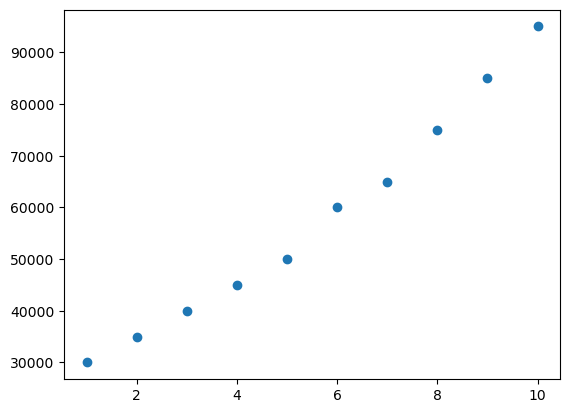

In [6]:
plt.scatter(data['Experience'],data['Salary'])
plt.show()

###### find the strength of the linear relationship

In [7]:
corr=data.corr()

In [8]:
corr

,Experience,Salary
Experience,1.000000,0.989433
Salary,0.989433,1.000000


In [9]:
X

,Experience
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [10]:
y

0    30000
1    35000
2    40000
3    45000
4    50000
5    60000
6    65000
7    75000
8    85000
9    95000
Name: Salary, dtype: int64

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model=LinearRegression()

In [13]:
## train the model
model.fit(X,y)

LinearRegression()

In [14]:
yhat=model.predict(X)

In [15]:
yhat

array([25818.18181818, 32969.6969697 , 40121.21212121, 47272.72727273,
       54424.24242424, 61575.75757576, 68727.27272727, 75878.78787879,
       83030.3030303 , 90181.81818182])

### Evaluate the model

In [16]:
from sklearn.metrics import mean_squared_error,r2_score

In [17]:
mse=mean_squared_error(y,yhat)
rmse=np.sqrt(mse)
r_sqr=r2_score(y,yhat)
print(f'Mean Squared Error: {np.round(mse)}\nRoot Mean Squared Error:{np.round(rmse)}\nR_Squared:{np.round(r_sqr,2)}')

Mean Squared Error: 9060606.0
Root Mean Squared Error:3010.0
R_Squared:0.98


In [18]:
a=rmse/data['Salary'].mean()

In [19]:
print(f'the model has: {a*100}% error')

the model has: 5.189800106982364% error


# using statsmodel- OLS

In [20]:
import statsmodels.formula.api as smf

In [21]:
model=smf.ols('Salary~Experience',data=data).fit()
model.summary()

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\scipy\stats\_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     372.5
Date:                Tue, 19 May 2026   Prob (F-statistic):           5.39e-08
Time:                        19:29:33   Log-Likelihood:                -94.287
No. Observations:                  10   AIC:                             192.6
Df Residuals:                       8   BIC:                             193.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.867e+04   2298.990      8.120      0.000    1.34e+04     2.4e+04
Experience  7151.5152    370.516     19.302      0.000    6297.104    8005.926
==============================================================================
Omnibus:                        0.927   Durbin-Watson:                   0.614
Prob(Omnibus):                  0.629   Jarque-Bera (JB):                0.637
Skew:                           0.170   Prob(JB):                        0.727
Kurtosis:                       1.811   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
model

## multilinear regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
cars=pd.read_csv('Cars_4vars.csv')

In [25]:
cars.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


### visualize the relationship

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


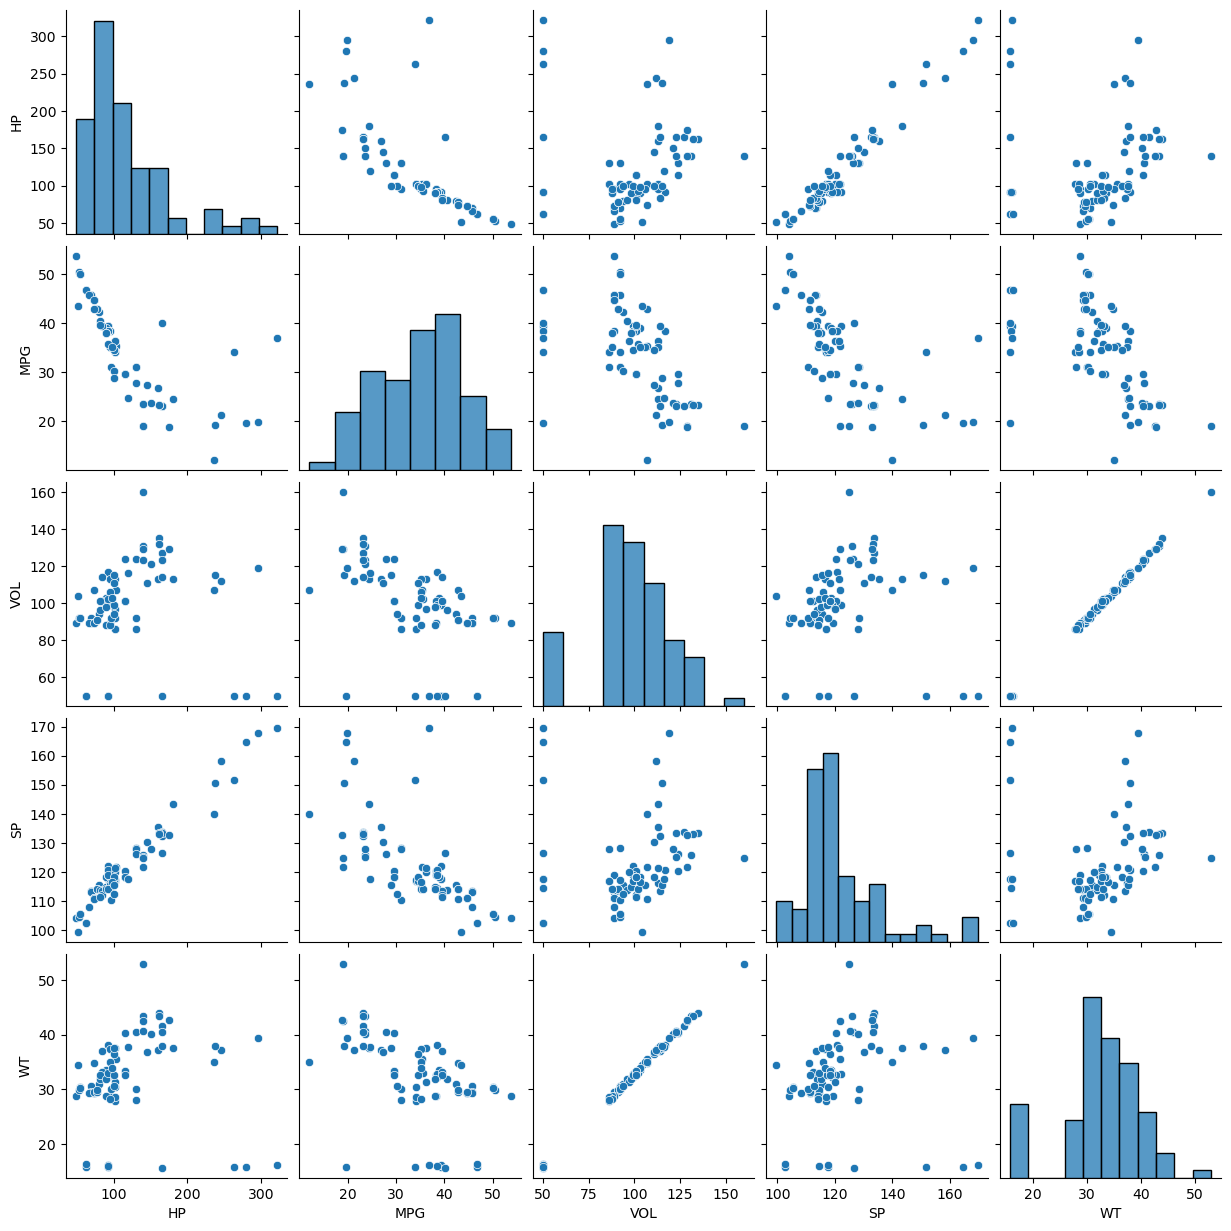

In [26]:
sns.pairplot(cars)

In [27]:
corr=cars.corr()

In [28]:
corr

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

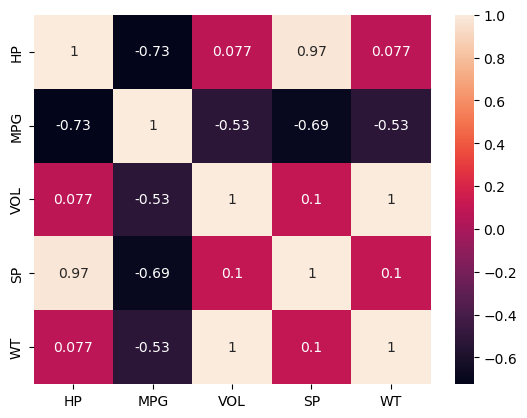

In [29]:
sns.heatmap(corr,annot=True)

In [30]:
model=smf.ols('MPG~SP+WT+VOL+HP',data=cars).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     63.80
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.54e-23
Time:                        19:29:43   Log-Likelihood:                -233.96
No. Observations:                  81   AIC:                             477.9
Df Residuals:                      76   BIC:                             489.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.6773     14.900      2.059      0.043       1.001      60.354
SP             0.3956      0.158      2.500      0.015       0.080       0.711
WT             0.4006      1.693      0.237      0.814      -2.972       3.773
VOL           -0.3361      0.569     -0.591      0.556      -1.469       0.796
HP            -0.2054      0.039     -5.239      0.000      -0.284      -0.127
==============================================================================
Omnibus:                       10.780   Durbin-Watson:                   1.403
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.722
Skew:                           0.707   Prob(JB):                      0.00285
Kurtosis:                       4.215   Cond. No.                     6.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [31]:
wt_model=smf.ols('MPG~WT',data=cars).fit()
wt_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     30.34
Date:                Tue, 19 May 2026   Prob (F-statistic):           4.38e-07
Time:                        19:29:43   Log-Likelihood:                -280.42
No. Observations:                  81   AIC:                             564.8
Df Residuals:                      79   BIC:                             569.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.2296      3.876     14.249      0.000      47.514      62.945
WT            -0.6420      0.117     -5.508      0.000      -0.874      -0.410
==============================================================================
Omnibus:                        2.735   Durbin-Watson:                   0.555
Prob(Omnibus):                  0.255   Jarque-Bera (JB):                2.045
Skew:                          -0.263   Prob(JB):                        0.360
Kurtosis:                       3.573   Cond. No.                         149.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
wtt_model=smf.ols('MPG~VOL',data=cars).fit()
wtt_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     30.71
Date:                Tue, 19 May 2026   Prob (F-statistic):           3.82e-07
Time:                        19:29:43   Log-Likelihood:                -280.28
No. Observations:                  81   AIC:                             564.6
Df Residuals:                      79   BIC:                             569.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.8171      3.957     14.106      0.000      47.941      63.693
VOL           -0.2166      0.039     -5.541      0.000      -0.294      -0.139
==============================================================================
Omnibus:                        2.691   Durbin-Watson:                   0.566
Prob(Omnibus):                  0.260   Jarque-Bera (JB):                1.997
Skew:                          -0.263   Prob(JB):                        0.368
Kurtosis:                       3.562   Cond. No.                         462.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
wttt_model=smf.ols('MPG~VOL+WT',data=cars).fit()
wttt_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     15.33
Date:                Tue, 19 May 2026   Prob (F-statistic):           2.43e-06
Time:                        19:29:43   Log-Likelihood:                -280.16
No. Observations:                  81   AIC:                             566.3
Df Residuals:                      78   BIC:                             573.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     56.8847      4.534     12.546      0.000      47.858      65.912
VOL           -0.6983      0.984     -0.710      0.480      -2.658       1.261
WT             1.4349      2.929      0.490      0.626      -4.397       7.266
==============================================================================
Omnibus:                        2.405   Durbin-Watson:                   0.591
Prob(Omnibus):                  0.300   Jarque-Bera (JB):                1.712
Skew:                          -0.251   Prob(JB):                        0.425
Kurtosis:                       3.506   Cond. No.                         597.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
model2=smf.ols('MPG~SP+VOL+HP',data=cars).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     86.11
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.56e-24
Time:                        19:29:43   Log-Likelihood:                -233.99
No. Observations:                  81   AIC:                             476.0
Df Residuals:                      77   BIC:                             485.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.9234     14.466      2.069      0.042       1.118      58.729
SP             0.4007      0.156      2.571      0.012       0.090       0.711
VOL           -0.2017      0.023     -8.928      0.000      -0.247      -0.157
HP            -0.2067      0.039     -5.353      0.000      -0.284      -0.130
==============================================================================
Omnibus:                       10.810   Durbin-Watson:                   1.389
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.822
Skew:                           0.704   Prob(JB):                      0.00271
Kurtosis:                       4.233   Cond. No.                     5.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### check for problematic records

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


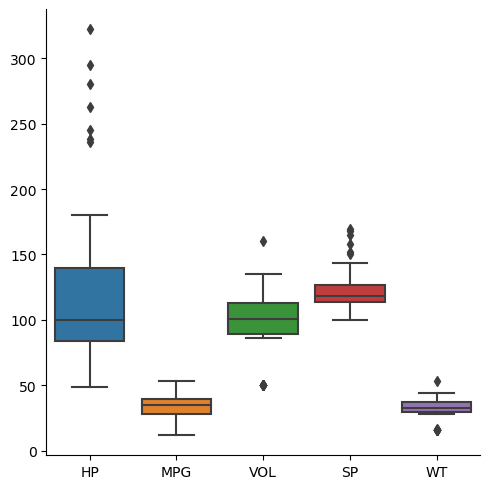

In [35]:
sns.catplot(cars,kind='box')
plt.show()

In [36]:
cars[cars['HP']>200]

,HP,MPG,VOL,SP,WT
69,245,21.273708,112,158.300669,37.141733
70,280,19.678507,50,164.598513,15.823060
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099
80,236,12.101263,107,139.840817,34.948615


In [37]:
idx=cars[cars['HP']>200].index.values
idx

array([69, 70, 76, 77, 78, 79, 80], dtype=int64)

In [38]:
cars.drop([69, 70, 76, 77, 78, 79, 80],inplace=True)

In [39]:
cars

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
71,162,23.203569,135,133.415985,44.013139
72,162,23.203569,132,133.140074,43.353123
73,140,19.086341,160,124.715241,52.997752
74,140,19.086341,129,121.864163,42.618698


In [40]:
cars=cars.drop('WT',axis=1)

In [41]:
cars.head()

,HP,MPG,VOL,SP
0,49,53.700681,89,104.185353
1,55,50.013401,92,105.461264
2,55,50.013401,92,105.461264
3,70,45.696322,92,113.461264
4,53,50.504232,92,104.461264


In [42]:
cars.shape

(74, 4)

In [43]:
final_model=smf.ols('MPG~VOL+WT',data=cars).fit()
final_model.summary()

PatsyError: Error evaluating factor: NameError: name 'WT' is not defined
    MPG~VOL+WT
            ^^

### using sklearn

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
x= cars.drop('MPG',axis=1)
y=cars['MPG']

In [ ]:
model=LinearRegression()
model.fit(x,y)

In [ ]:
yhat=model.predict(x)

### Evaluate the model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mse=mean_squared_error(y,yhat)
rmse=np.sqrt(mse)
r_sqr=r2_score(y,yhat)
print(f'Mean Squared Error: {np.round(mse)}\nRoot Mean Squared Error:{np.round(rmse)}\nR_Squared:{np.round(r_sqr,2)}')

In [ ]:
err_pct=np.round(rmse/cars['MPG'].mean(),2)
print(f'The model has {err_pct*100}% error')


In [ ]:
cars.shape

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
advertising=pd.read_csv('advertising.csv')

In [ ]:
advertising

In [ ]:
data_org=advertising.copy()

In [ ]:
data=advertising._get_numeric_data()

In [ ]:
data.head()

In [ ]:
data.rename(columns={'Daily Internet Usage':'Internet','Daily Time Spent on Site':'Time_Spent','Area Income':'area_income','Clicked on Ad':'clicked'},inplace=True)

In [ ]:
data

##### split data

In [ ]:
X=data.drop('clicked',axis=1)
y=data['clicked']

### build the model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# create model
model=LogisticRegression(max_iter=400)

In [ ]:
#train the model
model.fit(X,y)

In [ ]:
yhat=model.predict(X)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score,roc_curve,precision_score,recall_score,f1_score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cm=confusion_matrix(y,yhat)
sns.heatmap(cm,annot=True)

In [ ]:
cm=confusion_matrix(y,yhat)
sns.heatmap(cm,annot=True,cbar=False,fmt='d')

In [ ]:
def plot_roc(y,yhat):

    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y, yhat)
    print(f'AUC: {auc}')
    
    plt.figure(figsize=(3,3))
    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

In [ ]:
print(classification_report(y,yhat))

In [ ]:
plot_roc(y,yhat)

In [ ]:
model.predict_proba(X)
probs=pd.DataFrame(model.predict_proba(X),columns=['Will not clik','Will Click'])
probs.head()

In [ ]:
def get_classes():
    cutoff=0.6
    if x>=cutoff:
        res=1
    else:
        res=0
    return res

In [ ]:
probs['actual_y']=y

In [ ]:
probs['y_0.6']=probs['Will Click'].apply(get_classes)

In [ ]:
accuracy_score=probs['actual_y',]


# Split the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=data.drop('clicked',axis=1)
y=data['clicked']

In [ ]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
model.fit(X_train,y_train)

In [ ]:
yhat_train=model.predict(X_train)

In [ ]:
yhat_test=model.predict(X_test)

### k fold validation

In [ ]:
from sklearn.model_selection import KFold, cross_validate

In [ ]:
clf=LogisticRegression(max_iter=400)

In [ ]:
kfold=KFold(n_splits=5)

In [ ]:
results=cross_validate(clf,X,y,cv=kfold,scoring='accuracy',return_train_score=True)
results

In [ ]:
print(f"Training_accuracies: {results['train_score']}\n testing accuracies : {results['test_score']}")

### LeaveOne out validation

In [ ]:
from sklearn.model_selection import LeaveOneOut

In [ ]:
loocv=LeaveOneOut()

In [ ]:
clf=LogisticRegression(max_iter=400)

In [ ]:
kfold=KFold(n_splits=5)

In [ ]:
results=cross_validate(clf,X,y,cv=loocv,scoring='accuracy',return_train_score=True)
results

In [ ]:
results['test_score']

In [ ]:
results['test_score'].mean()

### Shuffle split

In [ ]:
from sklearn.model_selection import ShuffleSplit,cross_validate

In [ ]:
ssplit=ShuffleSplit(n_splits=100,test_size=0.2,random_state= 42)

In [ ]:
result=cross_validate(clf,X,y,cv=ssplit,scoring='accuracy', return_train_score=True)

In [ ]:
result['test_score']

### Encoding Categorical Data

In [ ]:
import pandas as pd

In [ ]:
iris= pd.read_csv('iris.csv')

In [ ]:
iris

In [ ]:
df1=iris.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
enc=LabelEncoder()
df1['species']=enc.fit_transform(df1['species'])
df1

# One hot Encoding: sklearn

In [ ]:
df2=iris.copy()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
one=OneHotEncoder()
one.fit_transform(df2[['species']])

In [ ]:
one.fit_transform(df2[['species']]).toarray()

In [ ]:
one=OneHotEncoder(sparse_output=False)
one.fit_transform(df2[['species']])

In [ ]:
one=OneHotEncoder(sparse_output=False)
one.fit_transform(df2[['species']])

In [ ]:
one_df=pd.DataFrame(one.fit_transform(df2[['species']]))  ### make this a data frame 
with column names and then merge both dataframe i.e this one and that df2

In [44]:
# Step 1: Array ko wapas Pandas DataFrame banao aur columns ke naam do
one_df = pd.DataFrame(one.fit_transform(df2[['species']]), columns=['species_0', 'species_1', 'species_2'])

# Step 2: Purane df2 ke sath is naye one_df ko chipka do (Merge/Concat)
final_df = pd.concat([df2, one_df], axis=1)

# Step 3: Purana English wala column hata do kyunki ab numbers aa gaye hain
final_df.drop('species', axis=1, inplace=True)

final_df.head()

NameError: name 'one' is not defined

### Using Pandas

In [ ]:
df3=iris.copy()

In [ ]:
df3.head()

In [ ]:
pd.get_dummies(df3,drop_first=True)

In [ ]:
bost= pd.read_csv('boston.csv')
bost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### LinearRegression 

In [ ]:
X=bost.drop('House Price',axis=1)
y=bost['House Price']

In [ ]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet

In [ ]:
lreg=LinearRegression()
lreg.fit(X,y)

In [ ]:
lreg.coef_

In [ ]:
model_params=pd.DataFrame(lreg.coef_,index=X.columns,columns=['LinearReg'])

In [ ]:
model_params

### Lasso Regression

In [ ]:
lasso=Lasso(alpha=1.0)
lasso.fit(X,y)

In [ ]:
lasso.coef_

In [ ]:
model_params['Lasso']=lasso.coef_
model_params

### Ridge Regression

In [ ]:
ridge=Ridge(alpha=1.0)
ridge.fit(X,y)

In [ ]:
ridge.coef_

In [ ]:
model_params['Ridge']=ridge.coef_
model_params

### Elastic Net

In [ ]:
elastic= ElasticNet(l1_ratio=0.5,alpha=1.0)
elastic.fit(X,y)

In [ ]:
elastic.coef_

In [ ]:
model_params['Elastic']=elastic.coef_
model_params

In [ ]:
sns.catplot(model_params,x='LinearReg',y=model_params.index,kind='bar')
plt.show

In [ ]:
sns.catplot(model_params,x='Lasso',y=model_params.index,kind='bar')
plt.show

In [ ]:
sns.catplot(model_params,x='Elastic',y=model_params.index,kind='bar')
plt.show

### SVM( support vector machine )

In [6]:
pharma= pd.read_csv('Pharma_Industry.csv')

In [7]:
pharma

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [8]:
X=pharma.drop('Drug Response',axis=1)
y=pharma['Drug Response']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((400, 5), (100, 5), (400,), (100,))

### Build and train model

In [10]:
from sklearn.svm import SVC
model= SVC(C=1.0,kernel='rbf',gamma=1.0)
model.fit(X_train,y_train)

SVC(gamma=1.0)

#### evaluate the model on training data

In [11]:
def plot_roc(y,yhat):

    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y, yhat)
    print(f'AUC: {auc}')
    
    plt.figure(figsize=(3,3))
    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

In [12]:
from sklearn.metrics import accuracy_score, classification_report

yhat_train = model.predict(X_train)

# Ma'am ke eval_clf ki jagah humara standard Sklearn ka direct function
print("Training Accuracy:", accuracy_score(y_train, yhat_train) * 100)
print("\nClassification Report:\n", classification_report(y_train, yhat_train))

Training Accuracy: 90.5

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91       196
           1       0.95      0.86      0.90       204

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.90       400
weighted avg       0.91      0.91      0.90       400



### evaluate the model on testing data